In [ ]:
import pandas as pd
import numpy as np

### Carga y Primera Vista del Dataset

Este bloque de código carga los datos de ventas de un archivo CSV desde una URL remota en un DataFrame de Pandas llamado `df`. Luego, `df.head()` muestra las primeras 5 filas del DataFrame, lo que nos permite tener una visión rápida de la estructura de los datos, incluyendo columnas como `transaccion_id`, `cliente_id`, `fecha`, `categoria`, `item`, `cantidad` y `canal`.

In [2]:
url="https://raw.githubusercontent.com/JUAN-32/Parcial4_JuanCortez_2500952022/refs/heads/main/raw/clave_I_asociacion.csv"
df= pd.read_csv(url)
df.head()


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,I-T0001,I-C0019,2026-03-11,Bebidas,Agua,2,App
1,I-T0001,I-C0019,2026-03-11,Combos,Combo_infantil,2,App
2,I-T0001,I-C0019,2026-03-11,Postres,Tres_leches,1,App
3,I-T0002,I-C0071,2026-04-11,Postres,Helado,3,Tienda
4,I-T0002,I-C0071,2026-04-11,Platos,Pizza,1,Tienda


In [4]:
#Mostrar las dimenciones
df.shape

(679, 7)

### Dimensiones del DataFrame

`df.shape` nos indica el número de filas (registros) y columnas (variables) en nuestro conjunto de datos. En este caso, tenemos 679 transacciones y 7 atributos por cada transacción.

In [5]:
#columnas
df.columns

Index(['transaccion_id', 'cliente_id', 'fecha', 'categoria', 'item',
       'cantidad', 'canal'],
      dtype='object')

### Nombres de las Columnas

`df.columns` lista los nombres exactos de todas las columnas del DataFrame. Esto es útil para verificar los nombres y asegurarnos de que coinciden con nuestras expectativas, lo cual es crucial para futuras operaciones y análisis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  679 non-null    object
 1   cliente_id      679 non-null    object
 2   fecha           679 non-null    object
 3   categoria       679 non-null    object
 4   item            679 non-null    object
 5   cantidad        679 non-null    int64 
 6   canal           678 non-null    object
dtypes: int64(1), object(6)
memory usage: 37.3+ KB


### Información General del DataFrame

`df.info()` proporciona un resumen conciso del DataFrame, incluyendo el número total de entradas, el número de columnas, el conteo de valores no nulos para cada columna y el tipo de dato (`Dtype`). Esta información es fundamental para identificar rápidamente posibles problemas como valores faltantes y tipos de datos incorrectos que puedan requerir limpieza o conversión.

In [8]:
df.isnull().sum()


,0
transaccion_id,0
cliente_id,0
fecha,0
categoria,0
item,0
cantidad,0
canal,1


### Identificación de Valores Nulos

`df.isnull().sum()` calcula la cantidad de valores faltantes (nulos) en cada columna. Aquí se observa que la columna `canal` tiene 1 valor nulo, lo cual es un problema de calidad de datos que debe ser abordado antes del análisis para evitar errores o resultados sesgados.

In [9]:
df.duplicated().sum()

np.int64(1)

### Identificación de Filas Duplicadas

`df.duplicated().sum()` detecta y cuenta las filas que son idénticas en todas sus columnas. En este caso, se encontró 1 fila duplicada. Las filas duplicadas pueden inflar artificialmente el tamaño del dataset y distorsionar los resultados del análisis, por lo que su eliminación es una buena práctica de limpieza de datos.

In [9]:
columnas_asociacion = [
    "Family",
    "Hobbies",
    "Social_Club",
    "Political",
    "Professional",
    "Religious",
    "Support_Group"
]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
df.describe()

,cantidad
count,679.000000
mean,1.437408
std,0.771056
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,4.000000


### Estadísticas Descriptivas de 'Cantidad'

`df.describe()` genera estadísticas descriptivas de las columnas numéricas. Para la columna `cantidad`, se muestra el conteo, la media, la desviación estándar, los valores mínimo y máximo, y los cuartiles (25%, 50%, 75%). Esto nos da una idea de la distribución de las cantidades de productos comprados por transacción.

In [18]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Load the data - moved here to ensure df is always defined
url="https://raw.githubusercontent.com/JUAN-32/Parcial4_JuanCortez_2500952022/refs/heads/main/raw/clave_I_asociacion.csv"
df= pd.read_csv(url)
print("Data loaded successfully. Head of DataFrame:")
print(df.head())

print('\n--- Handling Data Quality Issues ---')

# 1. Handle missing values in 'canal' column
# For demonstration, we'll fill missing 'canal' values with the mode.
# You might choose to drop rows with missing values or use a different imputation strategy based on your domain knowledge.
if df['canal'].isnull().sum() > 0:
    most_frequent_canal = df['canal'].mode()[0]
    df['canal'].fillna(most_frequent_canal, inplace=True)
    print(f"Missing values in 'canal' filled with '{most_frequent_canal}'.")
else:
    print("No missing values found in 'canal'.")

# 2. Handle duplicated rows
# Dropping duplicate rows to ensure each transaction is unique.
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
if df.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.")
else:
    print("No duplicate rows found.")

print('\n--- Data Preparation for Association Rule Mining ---')
# To perform association rule mining, we need to transform the data into a one-hot encoded format.
# Each row should represent a transaction, and columns should represent items.
# The values indicate if an item was present in that transaction.

# Aggregate items by transaction_id
basket = (df.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Convert quantities to a boolean format (present/not present)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

print("Sample of the transactional data (one-hot encoded):")
print(basket_sets.head())

# Now, we can apply an association rule algorithm like Apriori.
# You'll need to install mlxtend if you haven't already: !pip install mlxtend

# Find frequent itemsets
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

print('\nFrequent Itemsets (min_support=0.05):')
print(frequent_itemsets.head())

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print('\nAssociation Rules (min_threshold=1 for lift):')
print(rules.head())

print('\n--- Further Steps ---')
print('You can adjust `min_support` and `min_threshold` values to find more or fewer rules.')
print('Consider analyzing the `antecedents` and `consequents` with metrics like `support`, `confidence`, and `lift`.')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Data loaded successfully. Head of DataFrame:
  transaccion_id cliente_id       fecha categoria            item  cantidad  \
0        I-T0001    I-C0019  2026-03-11   Bebidas            Agua         2   
1        I-T0001    I-C0019  2026-03-11    Combos  Combo_infantil         2   
2        I-T0001    I-C0019  2026-03-11   Postres     Tres_leches         1   
3        I-T0002    I-C0071  2026-04-11   Postres          Helado         3   
4        I-T0002    I-C0071  2026-04-11    Platos           Pizza         1   

    canal  
0     App  
1     App  
2     App  
3  Tienda  
4  Tienda  

--- Handling Data Quality Issues ---
Missing values in 'canal' filled with 'Tienda'.
Dropped 1 duplicate rows.

--- Data Preparation for Association Rule Mining ---
Sample of the transactional data (one-hot encoded):
item            Agua  Brownie  Cafe  Combo_ejecutivo  Combo_familiar  \
transaccion_id                                                         
I-T0001            1        0     0           

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_161/1563852939.py:49: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes i

### Reglas de Asociación Organizadas

Reglas de asociación filtradas y ordenadas por `lift` y `confidence`.

In [14]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from IPython.display import display

# Re-generate 'basket_sets' and 'rules' to ensure they are defined.
# This assumes 'df' has been loaded and preprocessed by previous cells (e.g., _60ubDy5H5q6).

# Aggregate items by transaction_id
basket = (df.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Convert quantities to a boolean format (present/not present)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Apply the encoding function. Using .map for robustness against FutureWarning.
basket_sets = basket.map(encode_units)

# Find frequent itemsets
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Filtrar y ordenar las reglas para una mejor interpretación
filtered_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1.5)]

# Ordenar por lift y luego por confidence
filtered_rules = filtered_rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

# Seleccionar las columnas más relevantes para mostrar
display_rules = filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print("Reglas de Asociación (ordenadas por Lift y Confidence, filtradas por confidence > 0.5 y lift > 1.5):")
display(display_rules)

print('\n--- Análisis Adicional ---')
print('Puedes ajustar los umbrales de `confidence` y `lift` para explorar diferentes niveles de fuerza en las asociaciones.')
print('Por ejemplo, puedes intentar `confidence > 0.6` o `lift > 2.0`.')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Reglas de Asociación (ordenadas por Lift y Confidence, filtradas por confidence > 0.5 y lift > 1.5):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
18,"(Hamburguesa, Soda)",(Papas),0.097561,0.740741,4.218107
23,(Papas),"(Hamburguesa, Soda)",0.097561,0.555556,4.218107
20,"(Soda, Papas)",(Hamburguesa),0.097561,0.833333,3.486395
9,(Papas),(Hamburguesa),0.131707,0.750000,3.137755
8,(Hamburguesa),(Papas),0.131707,0.551020,3.137755
0,(Cafe),(Pasta),0.102439,0.525000,2.562500
2,(Helado),(Combo_infantil),0.136585,0.549020,2.164404
3,(Combo_infantil),(Helado),0.136585,0.538462,2.164404
19,"(Hamburguesa, Papas)",(Soda),0.097561,0.740741,1.898148
15,(Papas),(Soda),0.117073,0.666667,1.708333



--- Análisis Adicional ---
Puedes ajustar los umbrales de `confidence` y `lift` para explorar diferentes niveles de fuerza en las asociaciones.
Por ejemplo, puedes intentar `confidence > 0.6` o `lift > 2.0`.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretación de Reglas de Asociación

Aquí se destacan las reglas de asociación más fuertes para insights de negocio.

### Visualización de las Reglas de Asociación

Los siguientes gráficos nos ayudarán a entender visualmente las relaciones de las reglas de asociación, mostrando la distribución de las métricas clave: `soporte`, `confianza` y `lift`.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

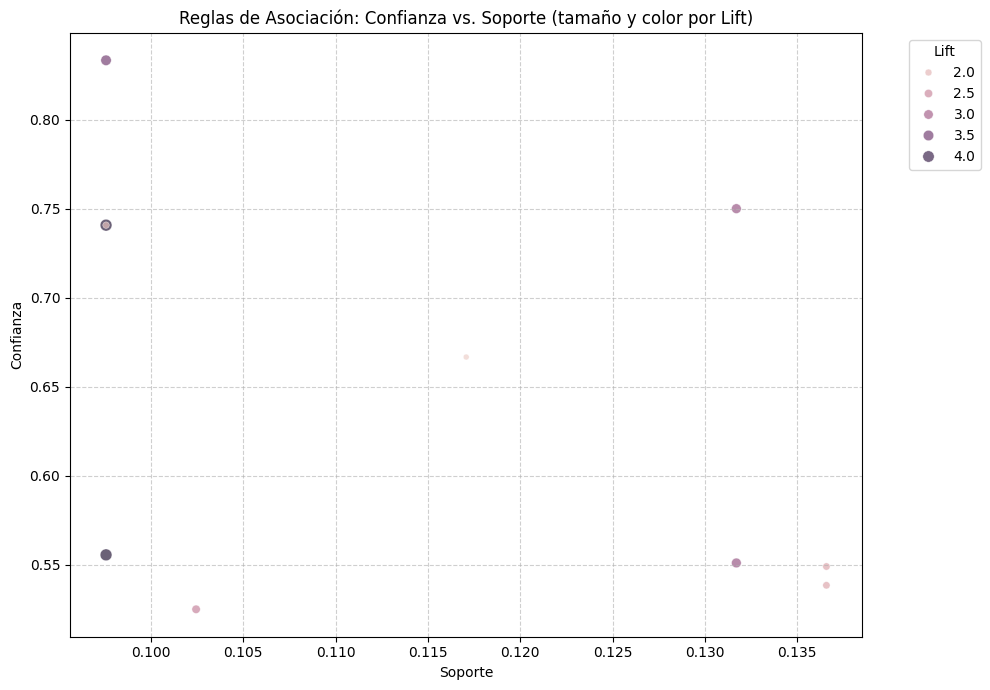

Interpretación: Relación entre Soporte, Confianza y Lift. Busque puntos en la parte superior derecha con colores intensos (alto lift).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure display_rules_plot is created if not already present
# This assumes 'display_rules' is available from cell b96c83cb
display_rules_plot = display_rules.copy()
display_rules_plot['antecedents'] = display_rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules_plot['consequents'] = display_rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))

# --- Scatter Plot: Confidence vs. Support, colored by Lift ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=display_rules_plot, alpha=0.7)
plt.xlabel("Soporte")
plt.ylabel("Confianza")
plt.title("Reglas de Asociación: Confianza vs. Soporte (tamaño y color por Lift)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Lift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Interpretación: Relación entre Soporte, Confianza y Lift. Busque puntos en la parte superior derecha con colores intensos (alto lift).")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

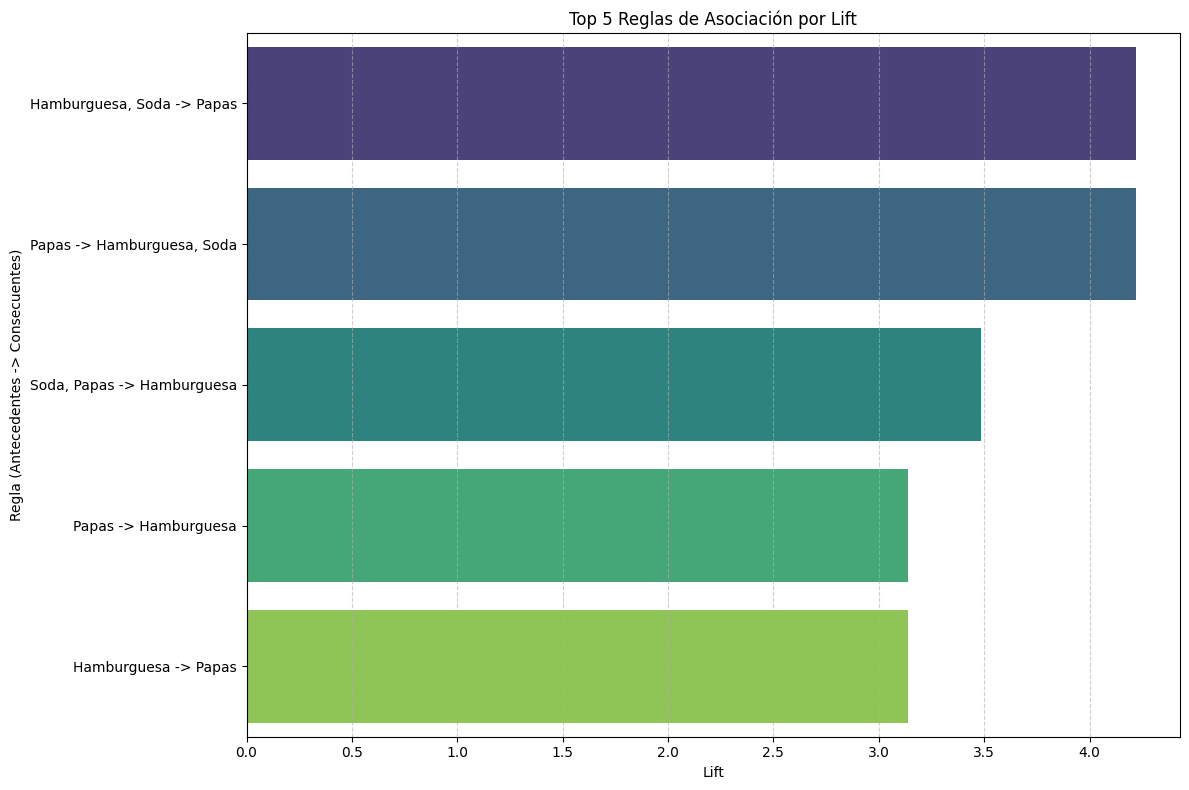

Interpretación: Las 5 reglas con el 'Lift' más alto, indicando las asociaciones más sorprendentes y valiosas.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure display_rules_plot is created and 'rule' column is added
# This assumes 'display_rules' is available from cell b96c83cb
display_rules_plot = display_rules.copy()
display_rules_plot['antecedents'] = display_rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules_plot['consequents'] = display_rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules_plot['rule'] = display_rules_plot.apply(lambda row: f"{row['antecedents']} -> {row['consequents']}", axis=1)

# --- Bar Chart: Top 5 rules by Lift ---
top_rules_lift = display_rules_plot.nlargest(5, 'lift')

plt.figure(figsize=(12, 8))
sns.barplot(x="lift", y="rule", data=top_rules_lift, palette="viridis")
plt.xlabel("Lift")
plt.ylabel("Regla (Antecedentes -> Consecuentes)")
plt.title("Top 5 Reglas de Asociación por Lift")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Interpretación: Las 5 reglas con el 'Lift' más alto, indicando las asociaciones más sorprendentes y valiosas.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

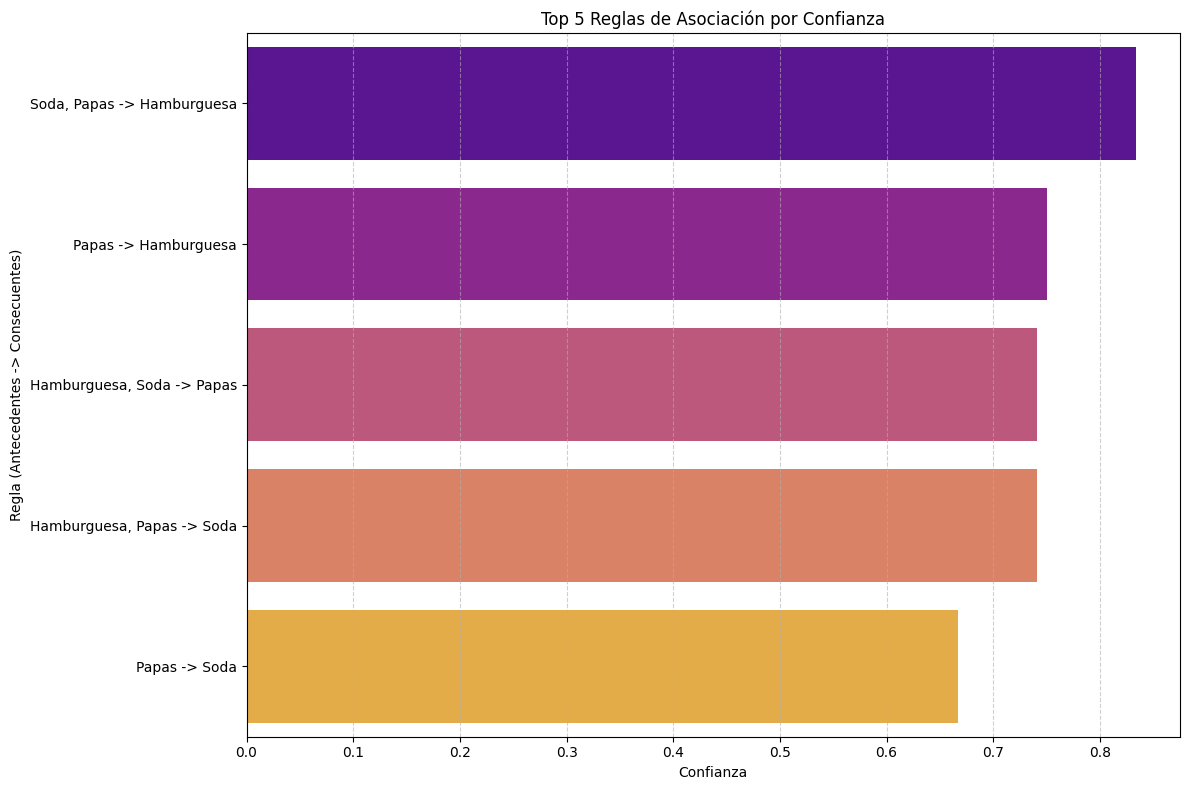

Interpretación: Las 5 reglas con la 'Confianza' más alta, mostrando las asociaciones más predictivas para recomendaciones directas.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure display_rules_plot is created and 'rule' column is added
# This assumes 'display_rules' is available from cell b96c83cb
display_rules_plot = display_rules.copy()
display_rules_plot['antecedents'] = display_rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules_plot['consequents'] = display_rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules_plot['rule'] = display_rules_plot.apply(lambda row: f"{row['antecedents']} -> {row['consequents']}", axis=1)

# --- Bar Chart: Top 5 rules by Confidence ---
top_rules_confidence = display_rules_plot.nlargest(5, 'confidence')

plt.figure(figsize=(12, 8))
sns.barplot(x="confidence", y="rule", data=top_rules_confidence, palette="plasma")
plt.xlabel("Confianza")
plt.ylabel("Regla (Antecedentes -> Consecuentes)")
plt.title("Top 5 Reglas de Asociación por Confianza")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Interpretación: Las 5 reglas con la 'Confianza' más alta, mostrando las asociaciones más predictivas para recomendaciones directas.")